In [ ]:
!pip install mgwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 817.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 670.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 11.8 MB/s eta 0:00:00


Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/1 [00:00<?, ?it/s]


=== Global Importance: MGWR (|β·x_std|) ===
  Feature  Mean |Contribution|  Percent (%)
0      x4               1.1953      19.7231
1      x2               1.1105      18.3238
2      x6               0.8778      14.4847
3      x1               0.7845      12.9454
4      x7               0.7228      11.9270
5      x3               0.6964      11.4917
6      x5               0.6730      11.1043

=== Global Importance: SHAP-adjusted ===
  Feature  Mean |Contribution|  Percent (%)
0      x4               1.1146      20.8258
1      x2               0.9794      18.2999
2      x6               0.7999      14.9458
3      x1               0.7066      13.2034
4      x7               0.6213      11.6097
5      x3               0.5762      10.7665
6      x5               0.5539      10.3489

=== Global Importance: RAW SHAP (features + spatial) ===
     Feature  Mean |Contribution|  Percent (%)
0         x4               1.1168    20.129000
1         x2               0.9774    17.617001
2         

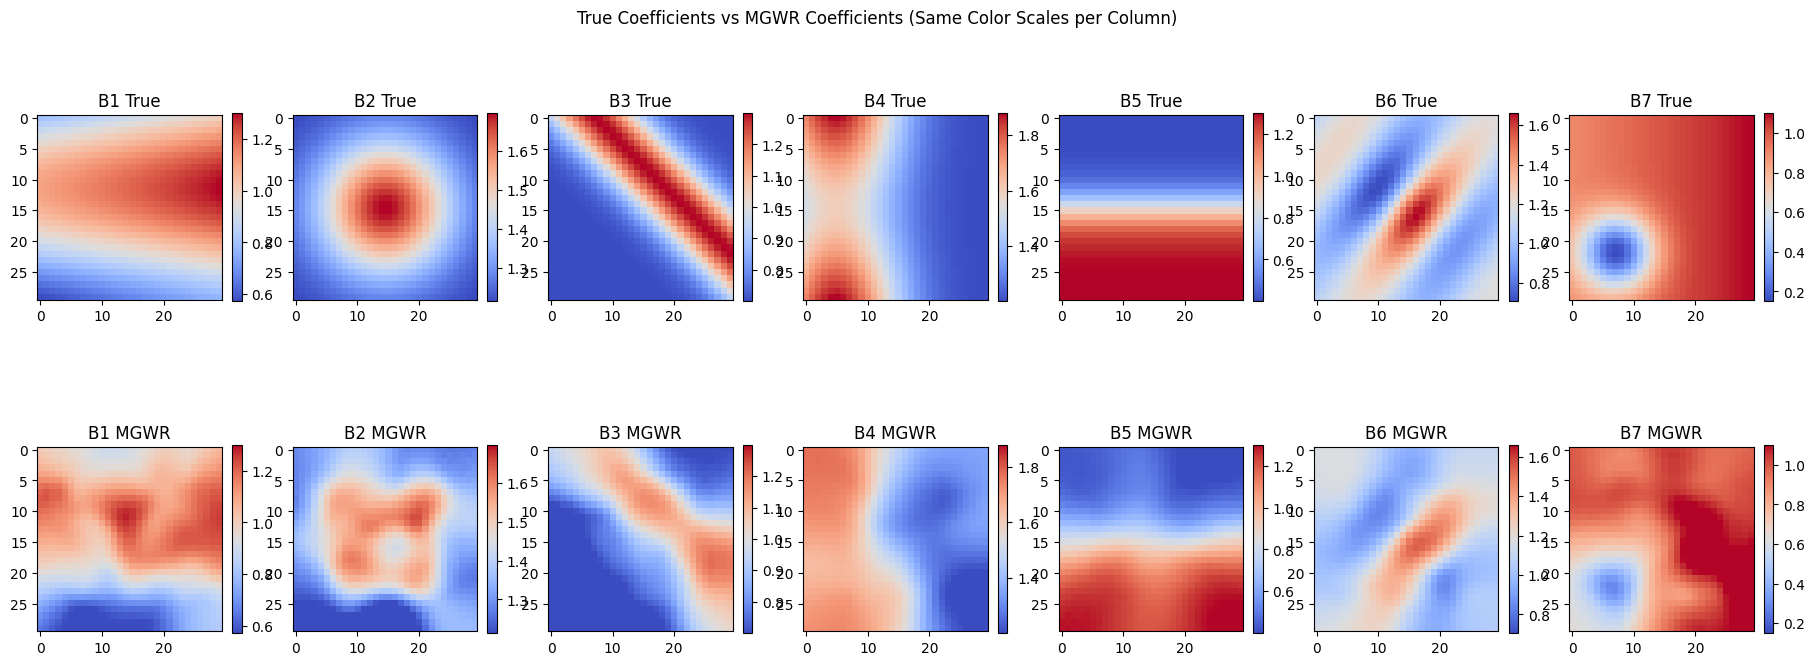

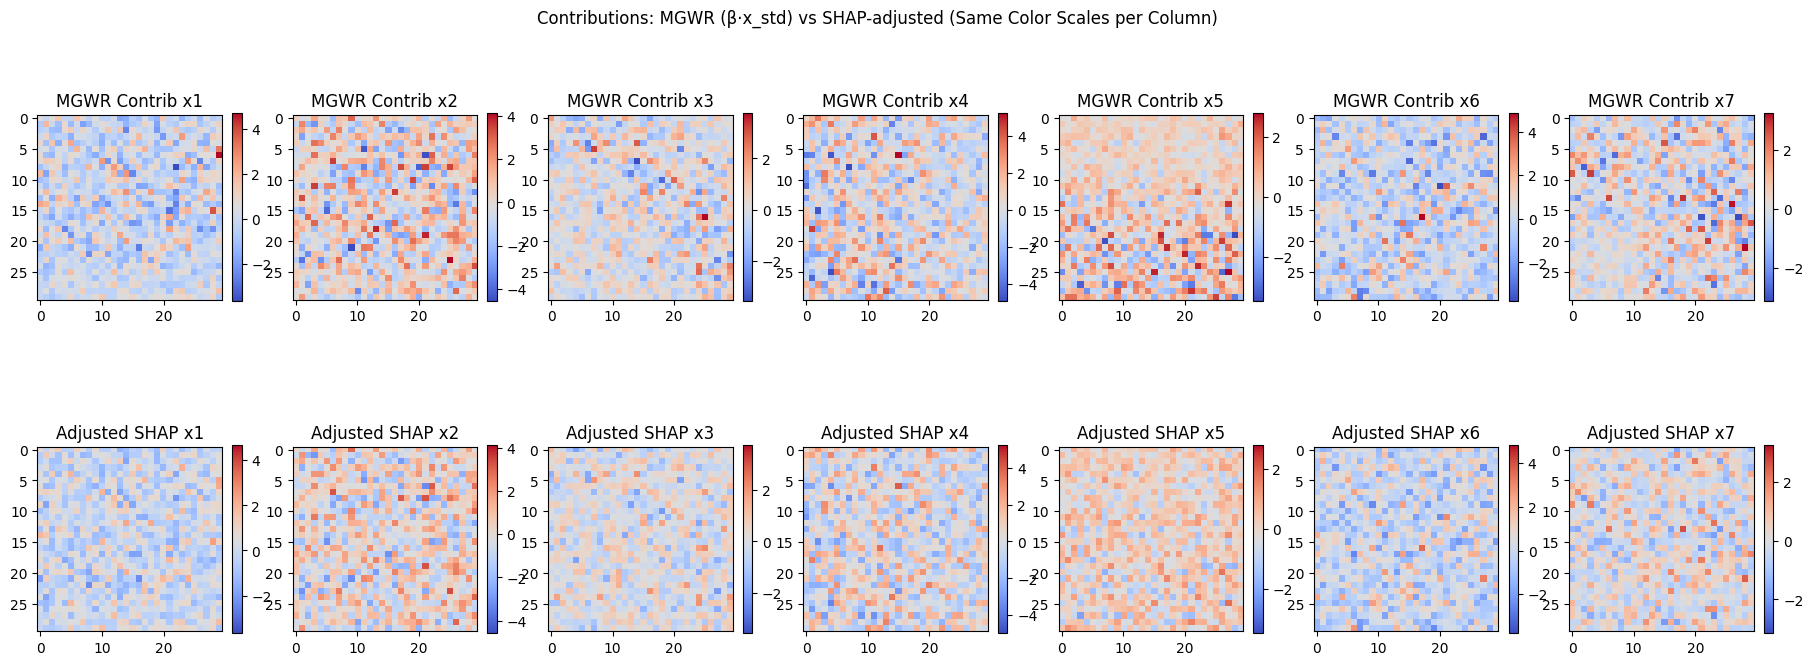

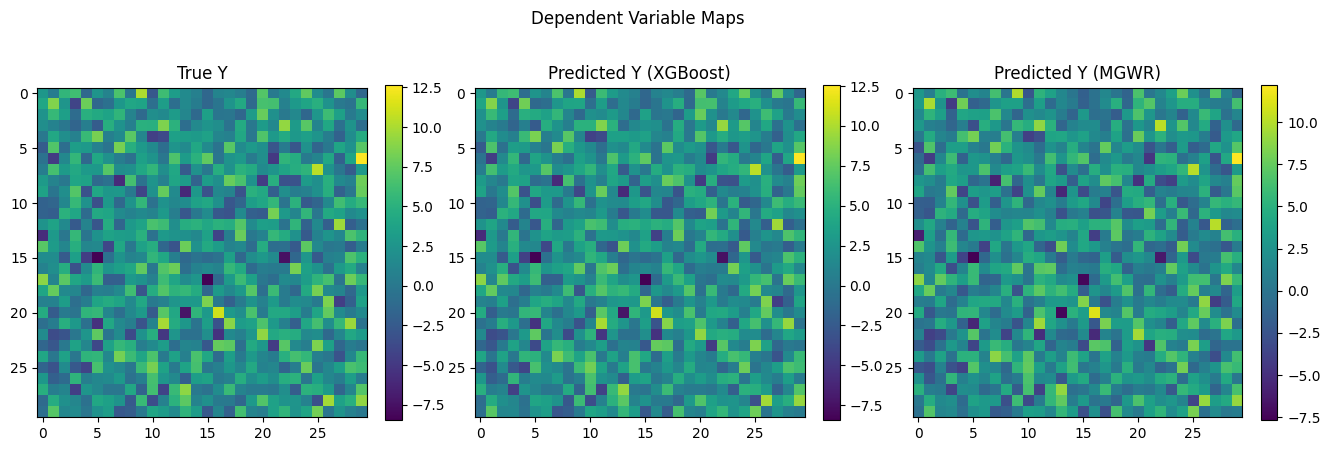

/tmp/ipython-input-1981795169.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)
/tmp/ipython-input-1981795169.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)


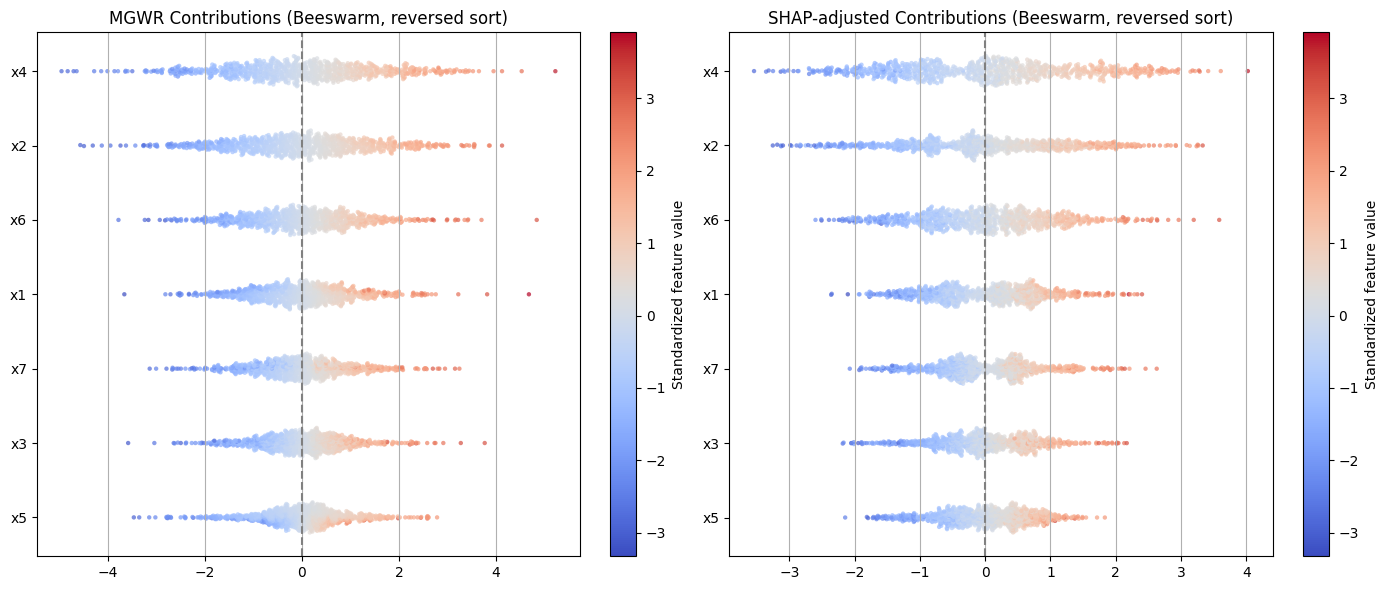

/tmp/ipython-input-1981795169.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)


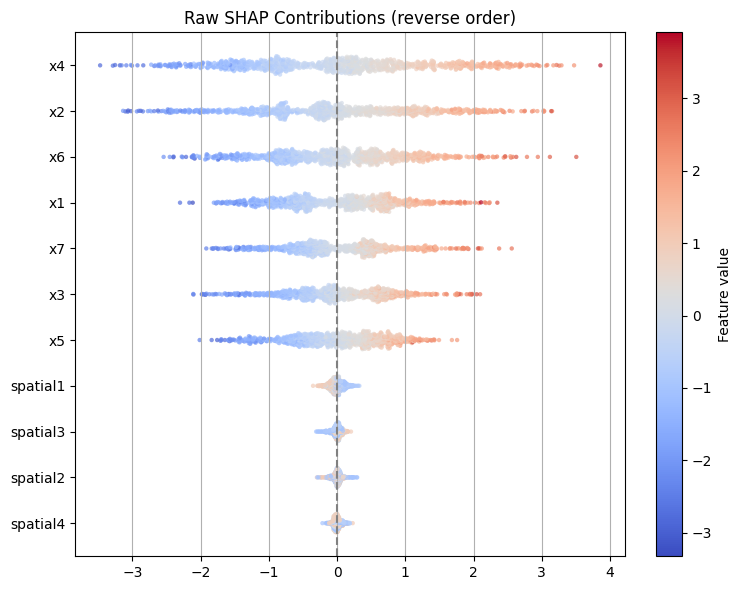


=== Global Importance: SHAP feature–spatial interactions ===
   Feature  Mean |Contribution|  Percent (%)
0    x2*S1               0.0165       5.8715
1    x3*S1               0.0164       5.8396
2    x4*S1               0.0150       5.3356
3    x7*S4               0.0132       4.6868
4    x4*S2               0.0130       4.6072
5    x7*S1               0.0124       4.4028
6    x1*S3               0.0123       4.3842
7    x2*S2               0.0113       4.0081
8    x2*S4               0.0113       4.0001
9    x5*S3               0.0111       3.9421
10   x6*S1               0.0105       3.7249
11   x1*S2               0.0100       3.5690
12   x6*S3               0.0095       3.3855
13   x1*S4               0.0093       3.3203
14   x5*S4               0.0091       3.2324
15   x4*S4               0.0091       3.2253
16   x4*S3               0.0091       3.2221
17   x3*S4               0.0088       3.1220
18   x3*S2               0.0084       2.9917
19   x7*S3               0.0084       

/tmp/ipython-input-1981795169.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)


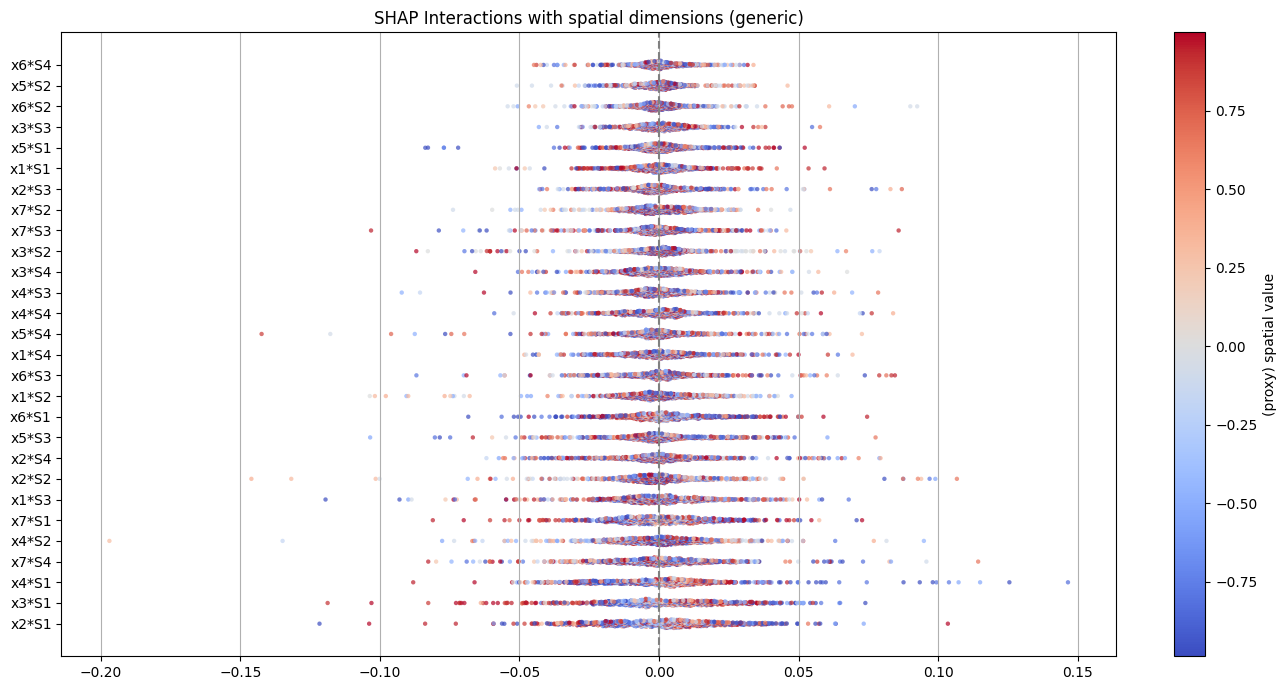

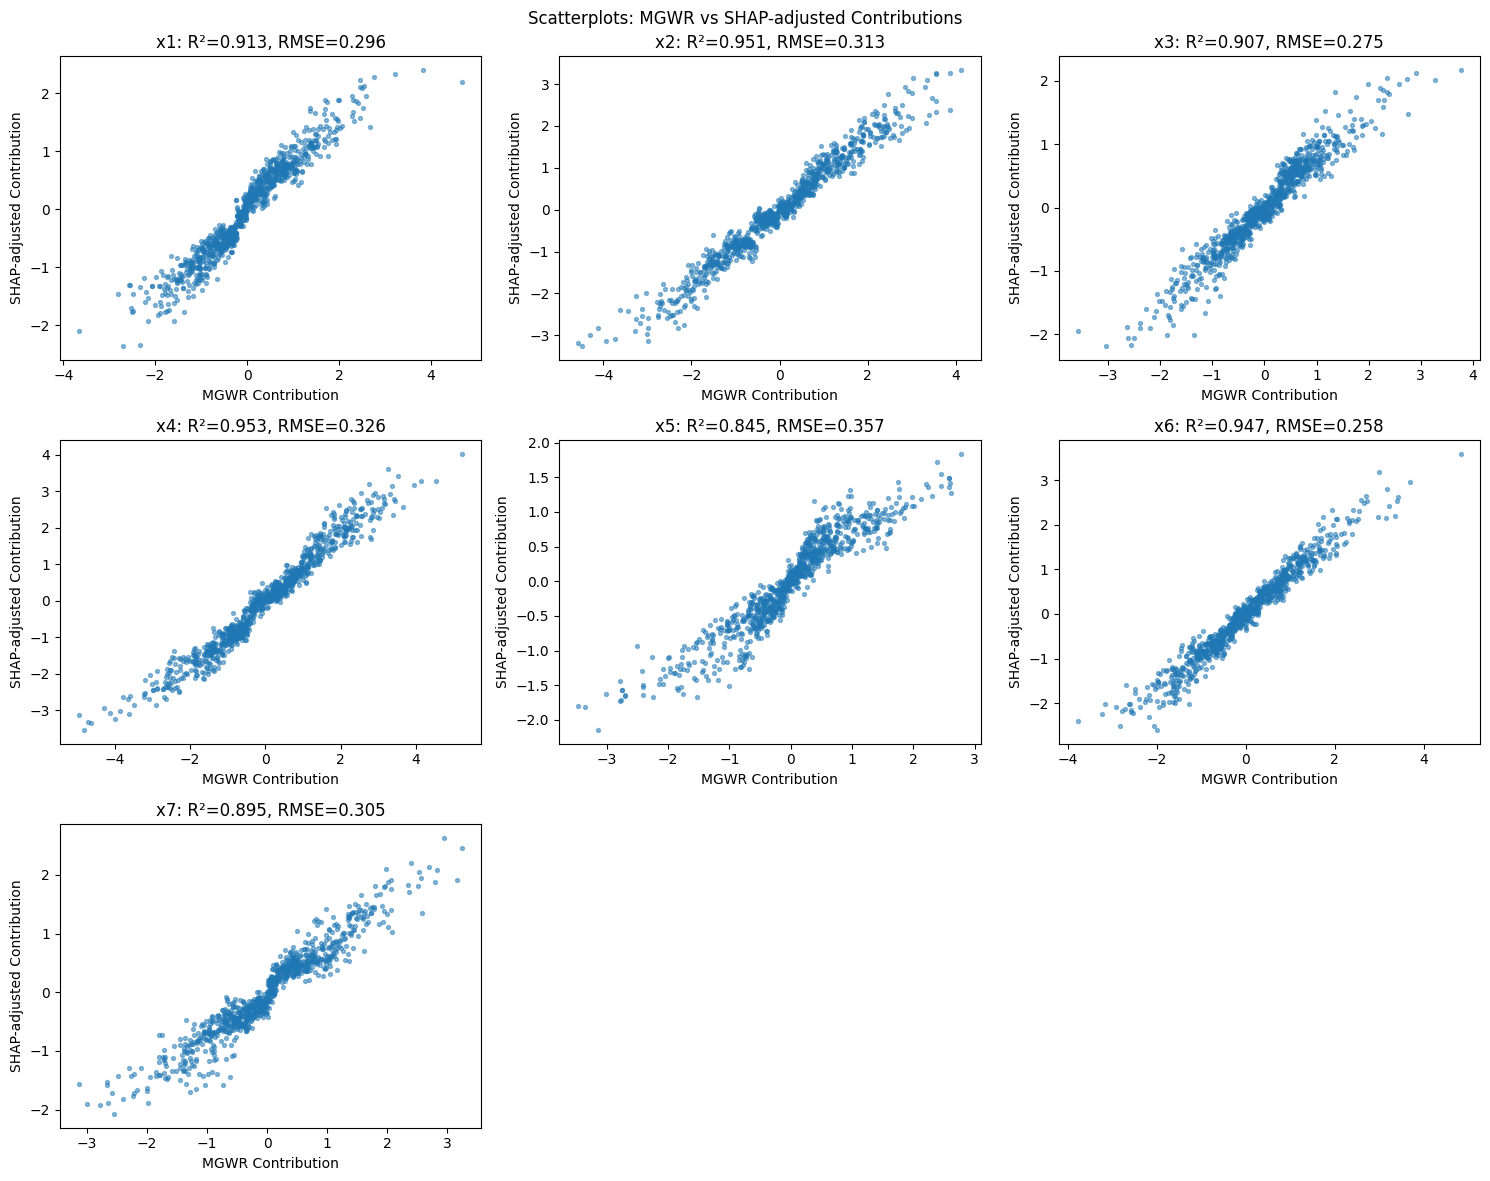

In [ ]:
# =========================
# 0) کتابخانه‌ها
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mgwr.gwr import MGWR
from mgwr.sel_bw import Sel_BW
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb
from matplotlib import cm
import math

# =========================
# 1) شبیه‌سازی داده‌ها (۷ ویژگی)
# =========================
np.random.seed(42)

n_side = 30
u = np.linspace(0, 12, n_side)
v = np.linspace(0, 12, n_side)
U, V = np.meshgrid(u, v)

# ضرایب واقعی (B0..B7) — وابسته به مکان
# B0_true = 2.5 * np.ones_like(U, dtype=float)
# B1_true = 0.8 + 0.2 * (U/12) + 0.3 * np.sin(V/3.0)
# B2_true = 1.2 + 0.5 * np.exp(-((U-6)**2 + (V-6)**2)/20.0)
# B3_true = 0.6 + 0.4 * (U/12) * (V/12)
# B4_true = 1.0 + 0.25 * np.cos(U/2.0) - 0.15 * np.sin(V/2.0)
# B5_true = 0.7 + 0.5 * (1.0/(1.0+np.exp(-(U-6))))   # سیگموئیدی در U
# B6_true = 1.0 + 0.3 * np.exp(-((U-10)**2+(V-2)**2)/15.0) - 0.2*np.cos((U+V)/4.0)
# B7_true = 0.9 + 0.2 * np.sin(U/3.0)*np.sin(V/3.0)


# --------- ضرایب جدید (B0..B7) با رفتارهای متمایز ----------
# B0: گرادیان خطی دو محوره
B0_true = 2.0 + 0.4 * (U/12.0) - 0.2 * (V/12.0)

# B1: قله شعاعی متمرکز در (9,3) + یک حلقه کاهش ملایم اطراف
#dist1 = np.sqrt((U-9.0)**2 + (V-3.0)**2)
#B1_true = 0.5 + 1.0 * np.exp(-dist1**2 / 8.0) - 0.3 * np.exp(-dist1**2 / 30.0)
B1_true = 0.8 + 0.2 * (U/12) + 0.3 * np.sin(V/3.0)

# B2: الگوی شطرنجی/نوسانی دو بعدی (موزاییکی منتظم)
#B2_true = 1.0 + 0.5 * np.sin(2.0 * np.pi * U / 4.0) * np.sin(2.0 * np.pi * V / 4.0)
B2_true = 1.2 + 0.5 * np.exp(-((U-6)**2 + (V-6)**2)/20.0)

# B3: ریدج مورب (خط با افزایش) — مرکز خط مورب U ~ V + 3
B3_true = 0.7 + 0.6 * np.exp(-((U - V - 3.0)**2) / 10.0)

# B4: میرایی آنی‌سو (طولی در U) با تاثیر ملایم V
B4_true = 1.2 + 0.8 * np.exp(-((U - 2.0)**2) / 18.0) * (1.0 - 0.5 * np.exp(-((V - 6.0)**2) / 30.0))

# B5: گذار تیز در جهت V (سیگموئیدی)
B5_true = 0.4 + 0.9 * (1.0 / (1.0 + np.exp(-(V - 6.0) / 0.8)))

# B6: موج ترکیبی U+V با دامنه‌ای که به مرکز (6,6) وابسته است (کاهش امپلی‌تود)
r2 = (U-6.0)**2 + (V-6.0)**2
B6_true = 1.1 + (0.6 * np.sin(U/1.5 + V/2.0)) / (1.0 + 0.08 * r2)

# B7: گودال محلی منفی نزدیک (3,9) + روند ملایم افزایشی در U
dist7 = np.sqrt((U-3.0)**2 + (V-9.0)**2)
B7_true = 0.9 - 0.8 * np.exp(-dist7**2 / 6.0) + 0.2 * (U/12.0)

# فیچرهای خام x1..x7 (پیچیده/غیرخطی)
# x1 = np.random.normal(0, 1, size=U.shape); x1 = np.where(x1 < 0, x1**2, x1)
# x2 = np.random.normal(0, 1, size=U.shape); x2 = np.tanh(x2)
# x3 = np.random.normal(0, 1, size=U.shape); x3 = np.sin(x3) + 0.1*x3
# x4 = np.random.normal(0, 1, size=U.shape); x4 = np.sign(x4) * np.sqrt(np.abs(x4))
# x5 = np.random.normal(0, 1, size=U.shape); x5 = 1/(1+np.exp(-x5))
# x6 = np.random.normal(0, 1, size=U.shape); x6 = np.cos(x6)
# x7 = np.random.normal(0, 1, size=U.shape); x7 = np.where(x7 > 0, np.log1p(x7), -np.log1p(-x7))

# x1 = np.random.normal(0, 1, size=U.shape); x1 = x1
# x2 = np.random.normal(0, 1, size=U.shape); x2 = x2
# x3 = np.random.normal(0, 1, size=U.shape); x3 = x3
# x4 = np.random.normal(0, 1, size=U.shape); x4 = x4
# x5 = np.random.normal(0, 1, size=U.shape); x5 = x5
# x6 = np.random.normal(0, 1, size=U.shape); x6 = x6
# x7 = np.random.normal(0, 1, size=U.shape); x7 = x7




# ---------- features x1..x7 (nonlinear transforms, but independent of betas) ----------
x1 = np.random.normal(0, 1, size=U.shape)
x2 = np.random.normal(0, 1, size=U.shape)
x3 = np.random.normal(0, 1, size=U.shape)
x4 = np.random.normal(0, 1, size=U.shape)
x5 = np.random.normal(0, 1, size=U.shape)
x6 = np.random.normal(0, 1, size=U.shape)
x7 = np.random.normal(0, 1, size=U.shape)

# # optional nonlinear transforms of features (keeps betas independent)
# x1 = np.tanh(x1)
# x2 = np.sign(x2) * np.sqrt(np.abs(x2)+1e-9)
# x3 = np.sin(x3) + 0.1 * x3
# x4 = 1/(1+np.exp(-x4))
# x5 = np.log1p(np.abs(x5)) * np.sign(x5)
# x6 = np.cos(x6)
# x7 = np.where(x7>0, np.log1p(x7), -np.log1p(-x7))

# نویز
eps = np.random.normal(0, 0.5, size=U.shape)

# y واقعی (ساختار خطی با ضرایب مکانی)
y = (
    B0_true
    + B1_true * x1
    + B2_true * x2
    + B3_true * x3
    + B4_true * x4
    + B5_true * x5
    + B6_true * x6
    + B7_true * x7
    + eps
)

coords = np.column_stack([U.ravel(), V.ravel()])
X_raw = np.column_stack([x1.ravel(), x2.ravel(), x3.ravel(), x4.ravel(),
                         x5.ravel(), x6.ravel(), x7.ravel()])
y_vec = y.ravel()
y_col = y_vec.reshape(-1, 1)

# =========================
# 2) استانداردسازی
# =========================
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

# =========================
# 3) MGWR
# =========================
n_features = X_std.shape[1]  # 7
X_mgwr = np.column_stack([np.ones(X_std.shape[0]), X_std])

selector = Sel_BW(coords, y_col, X_mgwr, spherical=False, multi=True)
_ = selector.search()  # باندویث‌ها
mgwr_model = MGWR(coords, y_col, X_mgwr, selector).fit()

# ضرایب مکانی برآوردی برای همه‌ی فیچرها
B_mgwr = [mgwr_model.params[:, j].reshape(U.shape) for j in range(1, n_features+1)]

# مشارکت MGWR = β_j(x,y) * x_j استانداردشده
mgwr_contrib_matrix = np.column_stack([
    B_mgwr[j].ravel() * X_std[:, j] for j in range(n_features)
])

y_pred_mgwr = (mgwr_model.params[:, 0] + mgwr_contrib_matrix.sum(axis=1)).reshape(U.shape)

# =========================
# 4) XGBoost + SHAP (spatial encoding)
# =========================
spatial_encoding = "space2vec"  # یکی از ["coords", "moran", "rbf", "space2vec"]

if spatial_encoding == "coords":
    X_spatial = coords

elif spatial_encoding == "moran":
    # جایگزین ساده (به‌جای Moran eigenvectors): PCA روی مختصات
    from sklearn.decomposition import PCA
    n_comp = min(10, coords.shape[1])  # = 2
    pca = PCA(n_components=n_comp)
    X_spatial = pca.fit_transform(coords)

elif spatial_encoding == "rbf":
    # پایه‌های شعاعی روی شبکه‌ی 5x5 => 25 بُعد مکانی
    centers_1d = np.linspace(0, 12, 5)
    Uc, Vc = np.meshgrid(centers_1d, centers_1d)
    centers = np.column_stack([Uc.ravel(), Vc.ravel()])
    gamma = 0.1
    X_spatial = np.exp(-gamma * ((coords[:, None, :] - centers[None, :, :])**2).sum(axis=2))

elif spatial_encoding == "space2vec":
    # نسخه‌ی سبک از positional encoding: چهار مؤلفه سین/کوس
    X_spatial = np.column_stack([
        np.sin(coords[:,0]), np.cos(coords[:,0]),
        np.sin(coords[:,1]), np.cos(coords[:,1])
    ])

else:
    raise ValueError("Unknown spatial_encoding")

n_spatial = X_spatial.shape[1]
X_ml = np.column_stack([X_std, X_spatial])

dtrain = xgb.DMatrix(X_ml, label=y_vec)
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 5,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}
xgb_model = xgb.train(params, dtrain, num_boost_round=250)
y_pred_xgb = xgb_model.predict(dtrain).reshape(U.shape)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_ml)                    # (N, p)
shap_interactions = explainer.shap_interaction_values(X_ml)  # (N, p, p)

# =========================
# 4b) SHAP adjusted (generalized)
# =========================
idx_x = list(range(n_features))
idx_spatial = list(range(n_features, n_features+n_spatial))

shap_adj_cols = []
for j in idx_x:
    # سهم خالص فیچر j + مجموع تعاملات j با همه‌ی ابعاد مکانی
    adj = shap_values[:, j].copy()
    for s in idx_spatial:
        adj += shap_interactions[:, j, s]
    shap_adj_cols.append(adj)

shap_contrib_matrix = np.column_stack(shap_adj_cols)

# =========================
# 5) اهمیت گلوبال
# =========================
feat_names = [f"x{i+1}" for i in range(n_features)]

def global_importance(contrib_matrix, feature_names):
    mean_abs = np.mean(np.abs(contrib_matrix), axis=0)
    total = mean_abs.sum()
    df = pd.DataFrame({
        "Feature": feature_names,
        "Mean |Contribution|": mean_abs,
        "Percent (%)": 100 * mean_abs / (total if total != 0 else 1.0)
    }).sort_values(by="Mean |Contribution|", ascending=False).reset_index(drop=True)
    return df

df_imp_mgwr = global_importance(mgwr_contrib_matrix, feat_names)
df_imp_shap = global_importance(shap_contrib_matrix, feat_names)

print("\n=== Global Importance: MGWR (|β·x_std|) ===")
print(df_imp_mgwr.round(4))
print("\n=== Global Importance: SHAP-adjusted ===")
print(df_imp_shap.round(4))

feat_names_full = feat_names + [f"spatial{i+1}" for i in range(n_spatial)]
df_imp_raw = global_importance(shap_values, feat_names_full)
print("\n=== Global Importance: RAW SHAP (features + spatial) ===")
print(df_imp_raw.round(4))

# =========================
# 6) سنجه‌ها: RMSE و R²
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / (ss_tot if ss_tot != 0 else 1.0)

print("\n=== RMSE / R²: MGWR-contrib vs SHAP-adjusted (per feature) ===")
for j, name in enumerate(feat_names):
    print(f"{name}:  RMSE = {rmse(mgwr_contrib_matrix[:, j], shap_contrib_matrix[:, j]):.4f}  |  "
          f"R² = {r2_score(mgwr_contrib_matrix[:, j], shap_contrib_matrix[:, j]):.4f}")

# ---- مقایسه ضرایب MGWR با ضرایب واقعی (برای هر 7 فیچر) ----
true_beta_maps = [B1_true, B2_true, B3_true, B4_true, B5_true, B6_true, B7_true]
est_beta_maps  = B_mgwr  # لیست 7تایی که بالاتر ساختیم

print("\n=== RMSE / R²: MGWR coefficients vs TRUE coefficients ===")
for j, name in enumerate(feat_names):
    print(f"β_{name}:  RMSE = {rmse(true_beta_maps[j].ravel(), est_beta_maps[j].ravel()):.4f}  |  "
          f"R² = {r2_score(true_beta_maps[j].ravel(), est_beta_maps[j].ravel()):.4f}")

# =========================
# 7) پلات‌ها (دینامیک برای n_features)
# =========================
cmap = 'coolwarm'

# --- (1) نقشه ضرایب واقعی و MGWR با مقیاس رنگی یکسان در هر ستون ---
fig, axes = plt.subplots(2, n_features, figsize=(3.2*n_features, 7.5))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for j in range(n_features):
    vmin, vmax = np.min(true_beta_maps[j]), np.max(true_beta_maps[j])

    im1 = axes[0, j].imshow(true_beta_maps[j], cmap=cmap)
    axes[0, j].set_title(f"B{j+1} True")
    plt.colorbar(im1, ax=axes[0, j], fraction=0.046)

    im2 = axes[1, j].imshow(est_beta_maps[j], cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, j].set_title(f"B{j+1} MGWR")
    plt.colorbar(im2, ax=axes[1, j], fraction=0.046)

plt.suptitle("True Coefficients vs MGWR Coefficients (Same Color Scales per Column)")
plt.show()

# --- (2) نقشه مشارکت‌ها: MGWR vs SHAP-adjusted (مقیاس یکسان در هر ستون) ---
fig, axes = plt.subplots(2, n_features, figsize=(3.2*n_features, 7.5))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for j, name in enumerate(feat_names):
    mgwr_map = mgwr_contrib_matrix[:, j].reshape(U.shape)
    shap_map = shap_contrib_matrix[:, j].reshape(U.shape)
    vmin = min(mgwr_map.min(), shap_map.min())
    vmax = max(mgwr_map.max(), shap_map.max())

    im1 = axes[0, j].imshow(mgwr_map, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, j].set_title(f"MGWR Contrib {name}")
    plt.colorbar(im1, ax=axes[0, j], fraction=0.046)

    im2 = axes[1, j].imshow(shap_map, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, j].set_title(f"Adjusted SHAP {name}")
    plt.colorbar(im2, ax=axes[1, j], fraction=0.046)

plt.suptitle("Contributions: MGWR (β·x_std) vs SHAP-adjusted (Same Color Scales per Column)")
plt.show()

# --- (3) نقشه y واقعی، y پیش‌بینی XGBoost، y پیش‌بینی MGWR ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in zip(
    axes,
    [y, y_pred_xgb, y_pred_mgwr],
    ["True Y", "Predicted Y (XGBoost)", "Predicted Y (MGWR)"]
):
    im = ax.imshow(data, cmap="viridis")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Dependent Variable Maps")
plt.show()

# --- (4) Beeswarm کمکی ---
def plot_beeswarm(ax, contrib_matrix, X_for_color, feature_names, order_indices,
                  cmap='coolwarm', compress_factor=0.25, row_spacing=0.6,
                  colorbar_label="Standardized feature value"):
    cmap_fn = cm.get_cmap(cmap)
    vmin = min(X_for_color[:, j].min() for j in order_indices)
    vmax = max(X_for_color[:, j].max() for j in order_indices)
    norm = plt.Normalize(vmin, vmax)

    for pos, feat_idx in enumerate(order_indices):
        x_vals = contrib_matrix[:, feat_idx]
        color_vals = X_for_color[:, feat_idx]
        colors = cmap_fn(norm(color_vals))

        hist, bin_edges = np.histogram(x_vals, bins=100)
        bin_indices = np.digitize(x_vals, bin_edges) - 1
        per_bin_slot = {b: [] for b in range(100)}
        for i, b in enumerate(bin_indices):
            if 0 <= b < 100:
                per_bin_slot[b].append(i)

        y_offsets = np.zeros_like(x_vals, dtype=float)
        max_count = max(len(idxs) for idxs in per_bin_slot.values()) if per_bin_slot else 1

        for b, idxs in per_bin_slot.items():
            n = len(idxs)
            if n == 0:
                continue
            if n % 2 == 0:
                ys = np.arange(-n/2, n/2) + 0.5
            else:
                ys = np.arange(-(n//2), n//2 + 1)
            ys = (ys / max_count) * compress_factor
            for jj, idx in enumerate(idxs):
                y_offsets[idx] = ys[jj]

        ax.scatter(x_vals, pos * row_spacing + y_offsets, c=colors, s=10, alpha=0.7, linewidths=0)

    ax.set_yticks(np.arange(len(order_indices)) * row_spacing)
    ax.set_yticklabels([feature_names[i] for i in order_indices])
    ax.axvline(0, linestyle='--', color='gray')
    ax.grid(True, axis='x')

    sm = plt.cm.ScalarMappable(cmap=cmap_fn, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.046)
    cb.set_label(colorbar_label)

# ترتیب‌های معکوس برای MGWR و SHAP-adjusted
order_mgwr_desc = df_imp_mgwr["Feature"].map(lambda x: feat_names.index(x)).values
order_shap_desc = df_imp_shap["Feature"].map(lambda x: feat_names.index(x)).values
order_mgwr_asc = order_mgwr_desc[::-1]
order_shap_asc = order_shap_desc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_beeswarm(axes[0], mgwr_contrib_matrix, X_std, feat_names, order_mgwr_asc)
axes[0].set_title("MGWR Contributions (Beeswarm, reversed sort)")

plot_beeswarm(axes[1], shap_contrib_matrix, X_std, feat_names, order_shap_asc)
axes[1].set_title("SHAP-adjusted Contributions (Beeswarm, reversed sort)")
plt.tight_layout()
plt.show()

# --- (5a) Beeswarm برای RAW SHAP (features + spatial) با سورتِ معکوس ---
order_raw_desc = df_imp_raw["Feature"].map(lambda x: feat_names_full.index(x)).values
order_raw_asc = order_raw_desc[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
plot_beeswarm(ax, shap_values, X_ml, feat_names_full, order_raw_asc,
              colorbar_label="Feature value")
ax.set_title("Raw SHAP Contributions (reverse order)")
plt.tight_layout()
plt.show()

# --- (5b) Beeswarm تعاملات SHAP (feature–spatial) برای هر نوع کدگذاری مکانی ---
interaction_features = []
interaction_matrix = []

for j, name in enumerate(feat_names):          # فقط فیچرهای اصلی
    for s in range(n_features, n_features+n_spatial):
        inter_js = shap_interactions[:, j, s]
        interaction_matrix.append(inter_js)
        interaction_features.append(f"{name}*S{s-n_features+1}")

interaction_matrix = np.column_stack(interaction_matrix) if interaction_matrix else np.zeros((X_ml.shape[0], 0))

if interaction_matrix.shape[1] > 0:
    df_imp_inter = global_importance(interaction_matrix, interaction_features)
    print("\n=== Global Importance: SHAP feature–spatial interactions ===")
    print(df_imp_inter.round(4))

    order_inter_desc = df_imp_inter["Feature"].map(lambda x: interaction_features.index(x)).values
    # برای رنگ، از اولین بعد مکانی استفاده می‌کنیم (صرفاً جهت نمایش یکنواخت)
    color_mat = np.repeat(X_spatial[:, :1], interaction_matrix.shape[1], axis=1)

    fig, ax = plt.subplots(1, 1, figsize=(max(8, 0.25*interaction_matrix.shape[1] + 6), 7))
    plot_beeswarm(ax, interaction_matrix, color_mat,
                  interaction_features, order_inter_desc,
                  colorbar_label="(proxy) spatial value")
    ax.set_title("SHAP Interactions with spatial dimensions (generic)")
    plt.tight_layout()
    plt.show()

# --- (6) Scatterplot مقایسه MGWR و SHAP-adjusted (دینامیک) ---
ncols = 3
nrows = math.ceil(n_features / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

def _rmse(a, b): return np.sqrt(np.mean((a - b)**2))

for j in range(n_features):
    ax = axes[j]
    ax.scatter(mgwr_contrib_matrix[:, j], shap_contrib_matrix[:, j], alpha=0.5, s=8)
    r2 = r2_score(mgwr_contrib_matrix[:, j], shap_contrib_matrix[:, j])
    ax.set_title(f"{feat_names[j]}: R²={r2:.3f}, RMSE={_rmse(mgwr_contrib_matrix[:, j], shap_contrib_matrix[:, j]):.3f}")
    ax.set_xlabel("MGWR Contribution")
    ax.set_ylabel("SHAP-adjusted Contribution")

# پنهان کردن محورهای اضافه
for k in range(n_features, len(axes)):
    axes[k].axis('off')

plt.suptitle("Scatterplots: MGWR vs SHAP-adjusted Contributions")
plt.tight_layout()
plt.show()
